*Lez 14 21/04/26*

Module_3/sensitivity_analysis_2025_2026.slides

# Sensitivity analysis

## Basic ODE integration

We will use solve_ivp function from SciPy for solving ODEs. It supports:

* Initial value problems (IVPs)
* Stiff and non-stiff problems
* Various integration methods: RK45, RK23, Radau, BDF, LSODA

It requires:

* A function that defines your differential equation.
* The time range over which you want to solve the ODE.
* The starting value of your system — a list or array of initial conditions.
* The integration method.
* A NumPy array of time points at which to store the solution. If not set, it only returns a few key points*

Risolviamo un'equazione differenziale:

\frac{dy}{dt} = -ky

con $k = 0.4$ e $y_0 = 6$.

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.030e-01 ...  2.970e+01  3.000e+01]
        y: [[ 6.000e+00  5.315e+00 ...  4.198e-05  3.719e-05]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0


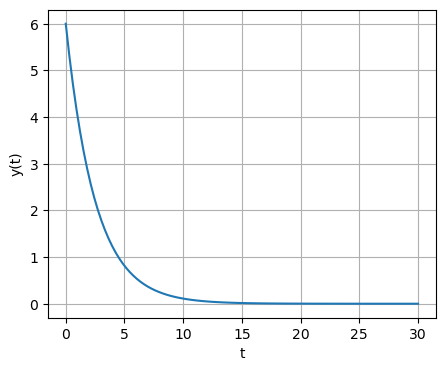

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# define the ODE
def model(t, y):    # must always take two arguments: time t and state y
    k = 0.4
    return -k * y

# time interval and initial condition
t_span = (0, 30)
y0 = [6]

# define time points at which to evaluate the solution
t_eval = np.linspace(t_span[0], t_span[1], 100)

# solve the ODE
sol = solve_ivp(model, t_span, y0, method='RK45', t_eval=t_eval)

# plot
plt.figure(figsize=(5,4))
plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

An optional input of `solve_ivp` function is `args` that allows additional information to be passed into the model function.

The `args` input is a tuple sequence of values.

Voglio far variare il valore del parametro.

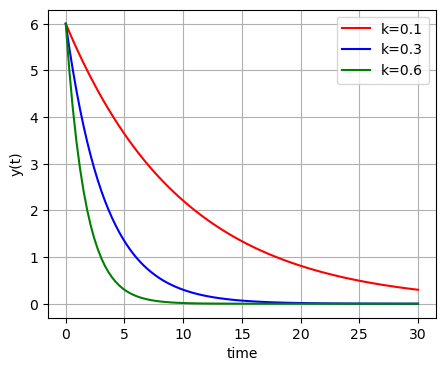

In [2]:
def model(t, y, k):
    dydt = -k*y
    return dydt

k = 0.1
sol1 = solve_ivp(model, t_span, y0, args=(k,), method='RK45', t_eval=t_eval)

k = 0.3
sol2 = solve_ivp(model, t_span, y0, args=(k,), method='RK45', t_eval=t_eval)

k = 0.6
sol3 = solve_ivp(model, t_span, y0, args=(k,), method='RK45', t_eval=t_eval)

plt.figure(figsize=(5,4))
plt.plot(sol1.t, sol1.y[0], 'r', label='k=0.1')
plt.plot(sol2.t, sol2.y[0], 'b', label='k=0.3')
plt.plot(sol3.t, sol3.y[0], 'g', label='k=0.6')
plt.xlabel('time')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend(loc='best')
plt.show()

## Logistic growth

The logistic growth is a classic model used to describe how a population grows in an environment with limited resources:

$\frac{dy}{dt} = ry(1 - \frac{y}{k})$

where $y(t)$ is the size of the population at time $t$, $r$ is the growth rate and $k$ is the carrying capacity, that is the number of people, other living organisms, or crops that a region can support without environmental degradation.

Descrive la crescita di una popolazione con poche risorse.

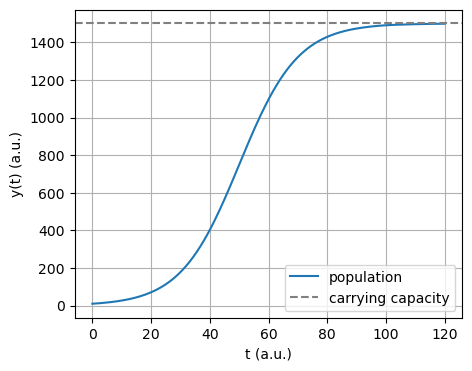

In [3]:
def logistic(t, y, r, k):
    dydt = r*y*(1 - y/k)
    return dydt

# initial condition
y0 = [10]

# time interval
t_span = (0, 120)

# time points at which to evaluate the solution
t_eval = np.linspace(t_span[0], t_span[1], 200)

# parameters
r = 0.1
k = 1500

# solve ODE
sol = solve_ivp(logistic, t_span, y0, args=(r, k), method='RK45', 
                t_eval=t_eval)

# plot
plt.figure(figsize=(5,4))
plt.plot(sol.t, sol.y[0], label='population')
plt.xlabel('t (a.u.)')
plt.ylabel('y(t) (a.u.)')
plt.grid(True)
plt.axhline(k, label='carrying capacity', color='gray', linestyle='--')
plt.legend(loc='best')
plt.show()

Sensitivity analysis for ODEs helps you understand **how sensitive the solution of an ODE is to changes in its parameters**. This is useful in modeling and simulations, especially **in contexts where parameters are often estimated or uncertain**.

Voglio vadere come varia la soluzione al variare dei parametri.

It is convenient to transform the result of the integration in a `pandas` dataframe. This allows us to use it for better visualization through `seaborn`.

In [6]:
import pandas as pd

def create_df(result, # dati principali da mettere in un dataframe
              columns, # nomi delle colonne del dataframe
              **other_info # argomenti opzionali con nome (keyword arguments), raccolti in un dizionario
              ):
    df = pd.DataFrame(result, columns=columns) # creo il dataframe con i dati principali
    for key, value in other_info.items():
        df[key] = value # aggiungo al dataframe le altre informazioni, una colonna per ogni chiave-valore
    return df

create_df(sol.y[0], # array con i dati della popolazione
          ['population'], # nome della colonna con i dati della popolazione
          r=r, k=k, # parametri del modello, sono colonne con valore costante;
                    # se r o k sono scalari, vengono ripetuti per tutte le righe del dataframe
                    # se r o k sono array, devono avere la stessa lunghezza di sol.y[0], e ogni riga del dataframe avrà un valore diverso di r o k
          time=sol.t # array con i dati del tempo
          ).head()

,population,r,k,time
0,10.000000,0.1,1500,0.000000
1,10.617168,0.1,1500,0.603015
2,11.272137,0.1,1500,1.206030
3,11.967188,0.1,1500,1.809045
4,12.704818,0.1,1500,2.412060


       population         r     k        time  simulation_run
0       10.000000  0.106382  1500    0.000000               0
1       10.657817  0.106382  1500    0.603015               0
2       11.358576  0.106382  1500    1.206030               0
3       12.105039  0.106382  1500    1.809045               0
4       12.900232  0.106382  1500    2.412060               0
...           ...       ...   ...         ...             ...
9995  1499.779334  0.143485  1500  117.587940              49
9996  1499.766906  0.143485  1500  118.190955              49
9997  1499.761699  0.143485  1500  118.793970              49
9998  1499.765128  0.143485  1500  119.396985              49
9999  1499.778689  0.143485  1500  120.000000              49

[10000 rows x 5 columns]


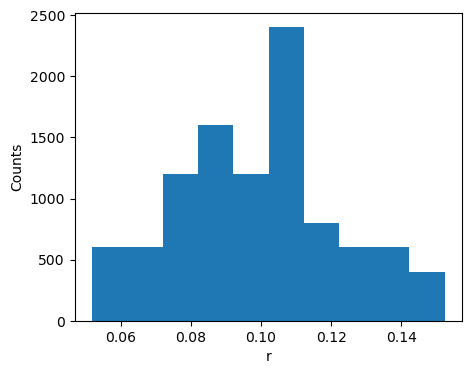

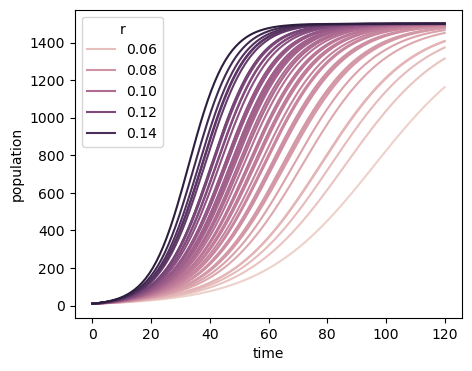

In [17]:
# randomly generate 50 normally distributed values of r
rates = np.random.normal(r, # media
                         0.02, # deviazione standard
                         50 # numero di valori da generare
                         )

results = [] # lista per raccogliere i dataframe con i risultati di ogni simulazione
idx = 0 # identificatore della simulazione

for ri in rates:
    sols = solve_ivp(logistic, t_span, y0, args=(ri, k), method='RK45', 
                     t_eval=t_eval)
    ys_df = create_df(sols.y[0], ['population'], r=ri, k=k, time=sols.t, 
                      simulation_run=idx)
    results.append(ys_df)
    idx = idx + 1

results = pd.concat(results, ignore_index=True) # unisce tutti i dataframe in uno solo,
                                                # ignorando gli indici originali e creando un nuovo indice continuo

print(results)

plt.figure(figsize=(5,4))
plt.hist(results['r'], bins=10)
plt.ylabel('Counts')
plt.xlabel('r')
plt.show()

import seaborn as sns

plt.figure(figsize=(5,4))
sns.lineplot(x="time", y="population", data=results, hue='r',
             estimator=None, units='simulation_run')
plt.show()


La variazione di *r* modifica principalemente la dinamica short term, dato che all'aumentare del tempo tutte le soluzioni convergono allo stesso risultato.

Quindi in questo caso l'incertezza sulla dimensione della popolazione nello short term è alta.

Facciamo variare *k*:

       population    r            k        time  simulation_run
0       10.000000  0.1  1444.440764    0.000000               0
1       10.616999  0.1  1444.440764    0.603015               0
2       11.271767  0.1  1444.440764    1.206030               0
3       11.966580  0.1  1444.440764    1.809045               0
4       12.703928  0.1  1444.440764    2.412060               0
...           ...  ...          ...         ...             ...
9995  1424.896180  0.1  1426.633494  117.587940              49
9996  1424.997728  0.1  1426.633494  118.190955              49
9997  1425.093343  0.1  1426.633494  118.793970              49
9998  1425.183374  0.1  1426.633494  119.396985              49
9999  1425.268150  0.1  1426.633494  120.000000              49

[10000 rows x 5 columns]


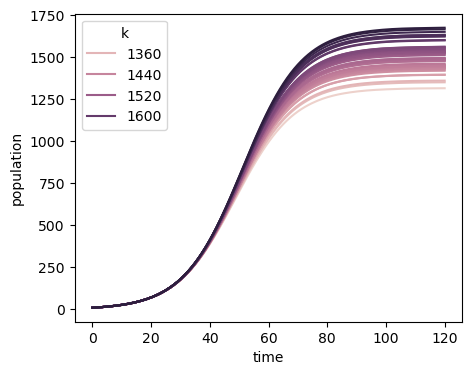

In [20]:
# randomly generate 50 normally distributed values of k
capacities = np.random.normal(k, 100, 50)

results = []
idx = 0
for ci in capacities:
    sols = solve_ivp(logistic, t_span, y0, args=(r, ci), method='RK45', 
                     t_eval=t_eval)
    ys_df = create_df(sols.y[0], ['population'], r=r, k=ci, time=sols.t, 
                      simulation_run=idx)
    results.append(ys_df)
    idx = idx + 1
results = pd.concat(results, ignore_index=True)

print(results)

plt.figure(figsize=(5,4))
sns.lineplot(x="time", y="population", data=results, hue='k',
             estimator=None, units='simulation_run')
plt.show()

Abbiamo fissato *r* e fatto variare *k*, in questo caso la dinamica short term è la stessa, invece quella long term varia.

# Sampling with noise

Sampling with noise is a powerful approach for **understanding how measurement noise or uncertainty in the data affects parameter estimation** in models like ODEs.

This can be done by:

* Introducing noise to the model (e.g., by adding Gaussian noise).
* Fitting the model to these noisy data points.
* Observing the covariation between the parameters after fitting the model, or how the fitted parameters change when there is noise in the data.

Voglio studiare come l'incertezza sui parametri modifica l'evoluzione.

Come l'errore simultaneo di *k* e *r* modificano il risultato?

Il modo più semplice di introdurre rumore è un rumore gaussiano.

Quindi ora dal risultato dell'esperimento voglio stimare i parametri con la loro incertezza.

Let's consider the logistic growth model.

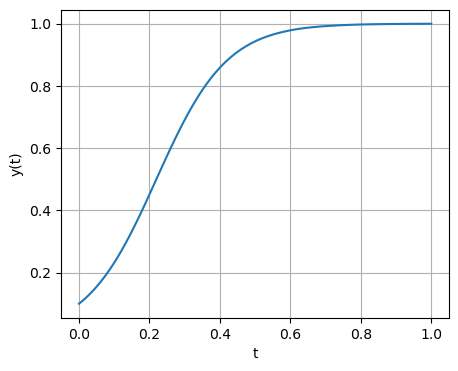

In [21]:
def logistic(t, y, r, k):
    dydt = r*y*(1 - y/k)
    return dydt

# initial condition
y0 = [0.1]

# time interval
t_span = (0, 1)

# time points at which to evaluate the solution
t_eval = np.linspace(t_span[0], t_span[1], 100)

# parameters
r = 10
k = 1

# solve ODE
sol = solve_ivp(logistic, t_span, y0, args=(r, k), method='RK45', 
                t_eval=t_eval)

plt.figure(figsize=(5,4))
plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

Questo è lo starting point della simulazione.

Let's add gaussian noise to our system. To this end, we can use the `rvs` function from `scipy.stats`.

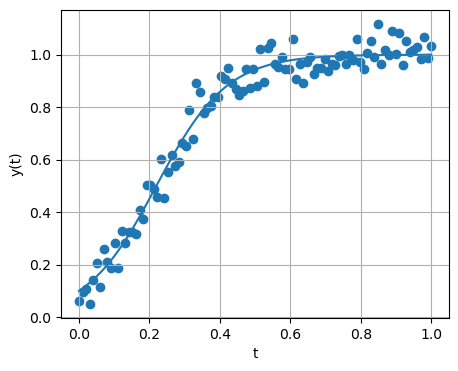

In [23]:
import scipy.stats as st

y_hat_normal = st.norm.rvs(loc=sol.y[0], scale=0.05)

plt.figure(figsize=(5,4))
plt.plot(sol.t, sol.y[0])
plt.scatter(sol.t, y_hat_normal)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

Questa funzione permette di generare variabli random attorno ad una curva.

## Fitting procedure

To fit the model to these noisy data points, we will use the `curve_fit` function from `scipy.optimize`, that will give us an estimate of the parameters and their correlations.

To do this, it takes a function that, given the x values and a set of parameters, it gives the prediction.

First of all, let's see how it works in the simple case of a linear regression:

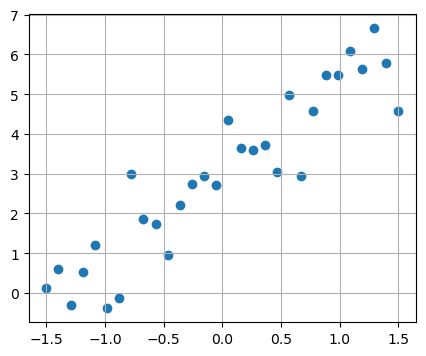

Estimated parameters: m=2.11, q=3.01
Covariance matrix:
[[2.71263045e-02 1.91485106e-11]
 [1.91485106e-11 2.17478135e-02]]


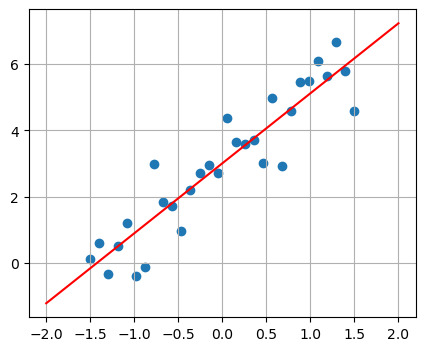

In [36]:
from scipy.optimize import curve_fit

x = np.linspace(-1.5, 1.5, 30)
y = 2*x + 3
y_noisy = st.norm.rvs(loc=y, scale=0.8)

plt.figure(figsize=(5,4))
plt.scatter(x, y_noisy)
plt.grid(True)
plt.show()

def linear_fit(xdata, m, q):
    return m*xdata + q

p_avg, p_cov = curve_fit(linear_fit, x, y_noisy, p0=[1, 0])

print(f"Estimated parameters: m={p_avg[0]:.2f}, q={p_avg[1]:.2f}")
print(f"Covariance matrix:\n{p_cov}")

x_values = np.linspace(-2, 2, 51)
y_hat = linear_fit(x_values, *p_avg)

plt.figure(figsize=(5,4))
plt.scatter(x, y_noisy)
plt.plot(x_values, y_hat, 'r')
plt.grid(True)
plt.show()

## How to visualize uncertainty?

* normal sampling
* 95% quantiles representation

### normal sampling

Creiamo una variabile in cui metto l'output di una distribuzione normale multivariata.
Usiamo questa distribuzione perché *m* e *q* sono correlati.


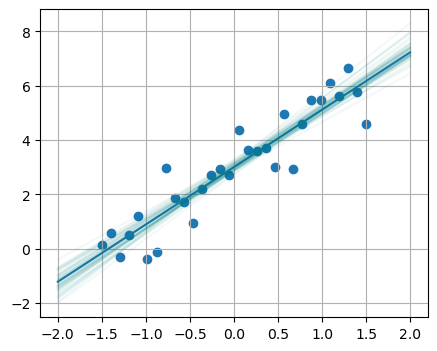

In [37]:
p_seq = st.multivariate_normal.rvs(mean=p_avg,
                                   cov=p_cov,
                                   size=50
                                   ) # genera 50 coppie di parametri (m, q) a partire dalla distribuzione
                                     # normale multivariata definita da p_avg e p_cov
x_base = np.linspace(-2, 2, 51)
y_hat = linear_fit(x_base, *p_avg)

plt.figure(figsize=(5,4))
plt.scatter(x, y_noisy)
plt.plot(x_base, y_hat)
plt.grid(True)

for params in p_seq:                        # per ogni coppia di parametri (m, q) generata
    y_hat = linear_fit(x_base, *params)     # calcola la retta corrispondente a quella coppia di parametri
    plt.plot(x_base, y_hat,
             color='teal', alpha=0.05)      # la disegna con trasparenza

Sto generando 50 linee rette.

Stiamo assumendo che la distribuzione dei parametri sia normale.

### 95% quantiles representation

Seleziono solo i valori nel 95o percentile.

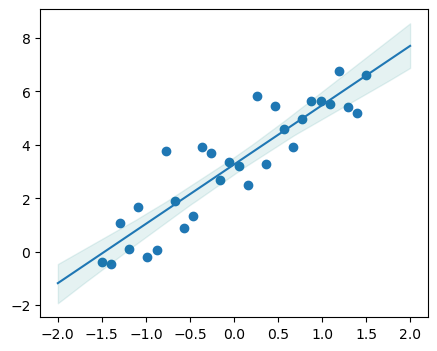

In [ ]:
from scipy.stats.mstats import mquantiles

p_seq = st.multivariate_normal.rvs(mean=p_avg, cov=p_cov, size=50)
x_base = np.linspace(-2, 2, 101)
y_hat = linear_fit(x_base, *p_avg)

plt.figure(figsize=(5,4))
plt.scatter(x, y_noisy)
plt.plot(x_base, y_hat)
y_hat = [linear_fit(x_base, *params) for params in p_seq]
y_hat = np.stack(y_hat)

p_low, p_top = mquantiles(y_hat, prob=[0.025, 0.975], axis=0)
plt.fill_between(x_base, p_low, p_top, alpha=0.1, color='teal')
plt.show()

Let's go back to logistic regression.

[10.05857716  0.99698396]


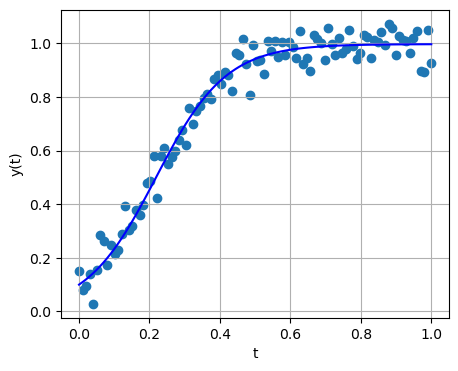

In [ ]:
def logistic_fit(xdata, r, k, y0=0.1):
    C = (k - y0) / y0
    return k / (1 + C * np.exp(-r * xdata))

p_avg, p_cov = curve_fit(logistic_fit,
                         t_eval,        # varabile indipendente (tempo)
                         y_hat_normal,  # dati osservati (con rumore)
                         p0=[1, 0.1]    # valori iniziali per i parametri r e k,
                                        # usati come punto di partenza per l'ottimizzazione
                         )

print(p_avg) # stima dei parametri r e k a partire dai dati rumorosi y_hat_normal

y_fit = logistic_fit(t_eval, *p_avg)

plt.figure(figsize=(5,4))
plt.scatter(t_eval, y_hat_normal)
plt.plot(t_eval, y_fit, 'b')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()


Ottengo il trend dei punti random generati.
Quindi posso stimare l'incertezza

### normal sampling

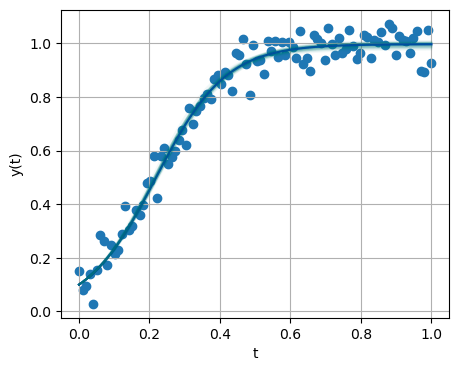

In [ ]:
p_seq = st.multivariate_normal.rvs(mean=p_avg, cov=p_cov, size=50)

plt.figure(figsize=(5,4))
plt.scatter(t_eval, y_hat_normal)
plt.plot(t_eval, y_fit, 'b')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
for params in p_seq:
    y_hat_ = logistic_fit(t_eval, *params)
    plt.plot(t_eval, y_hat_, color='teal', alpha=0.05)
plt.show()

C'è un'incertezza piccola attorno alla media.

### 95% quantiles representation

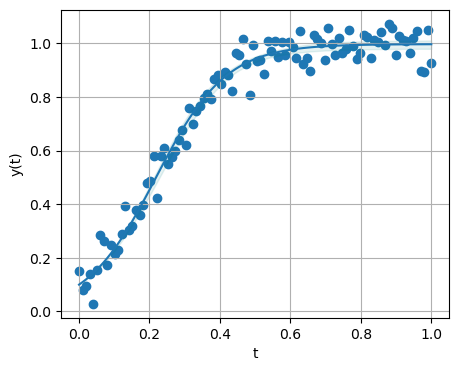

In [ ]:
p_seq = st.multivariate_normal.rvs(mean=p_avg, cov=p_cov, size=50)

plt.figure(figsize=(5,4))
plt.scatter(t_eval, y_hat_normal)
plt.plot(t_eval, y_fit)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
y_hat_2 = [logistic_fit(t_eval, *params) for params in p_seq]
y_hat_2 = np.stack(y_hat_2)

p_low, p_top = mquantiles(y_hat_2, prob=[0.025, 0.975], axis=0)
plt.fill_between(t_eval, p_low, p_top, alpha=0.1, color='teal')
plt.show()

# Sensitivity analysis in machine learning

Usiamo un pool di numeri scritti a mano.

Dividiamo il dataset in una parte per il training e uno per il test

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# MNIST dataset
transform = transforms.ToTensor() # converte le immagini in tensori PyTorch e normalizza i pixel tra 0 e 1
                                  # esempio: 255 -> 1.0, 128 -> 0.5, 0 -> 0.0
                                  # questo è importante perché le reti neurali lavorano meglio con input normalizzati

train_loader = torch.utils.data.DataLoader( # Qui si costruisce il dataset di addestramento
    datasets.MNIST('.',                     # cartella in cui salvare i dati ('.' indica la cartella corrente)
                   train=True,              # usa il dataset di addestramento
                   download=True,           # scarica i dati se non sono già presenti nella cartella
                   transform=transform      # applica ToTensor() a ogni immagine del dataset
                   ),
    batch_size=64,                          # prende 64 immagini alla volta per formare un batch,
                                            # che è l'unità di dati su cui la rete neurale viene addestrata in ogni passo
    shuffle=True                            # mescola i dati ad ogni epoca, in modo che la rete non veda
                                            # sempre le stesse immagini nello stesso ordine,
) 

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('.',
                   train=False,             # usa il dataset di test invece di quello di addestramento
                   transform=transform
                   ),
    batch_size=1
)

Nel modello abbiamo:
* Flatten per passare da un 28*28 ad un array 1 dim
* Linear
* ReLu dà il massimo tra 0 e x
* Linear

Poi performiamo il training.

In [5]:
# MLP
model = nn.Sequential(      # crea una rete in cui ogni layer è applicato in sequenza
    nn.Flatten(),           # layer 1: appiattisce l'immagine 28x28 in un vettore di 784 elementi
    nn.Linear(28*28, 64),   # layer 2: primo layer lineare con 64 neuroni, che prende in input i 784 pixel e produce 64 valori
    nn.ReLU(),              # layer 3: funzione di attivazione ReLU, che introduce non linearità tra il primo e il secondo layer lineare
    nn.Linear(64, 10)       # layer 4: secondo layer lineare con 10 neuroni, che prende in input i 64 valori del layer precedente
                            # e produce 10 valori, uno per ogni classe (cifra da 0 a 9)
)

# training
opt = optim.Adam(model.parameters(), lr=1e-3) # qui si sceglie come ottimizzare i parametri della rete
                                              # (i pesi dei layer lineari) a partire dai dati di addestramento,
                                              # usando l'algoritmo Adam con un tasso di apprendimento di 0.001
loss_fn = nn.CrossEntropyLoss() # loss function per problemi di classificazione multi-classe,
                                # che confronta le previsioni della rete (out) con le etichette vere (y) 

for epoch in range(5):          # allena per 5 epoche (passaggi completi su tutto il dataset di addestramento)
    for x, y in train_loader:   # x: immagini del batch, y: etichette vere del batch
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()

Selezioniamo un'immagine target (7)

In [6]:
# select a number
target_digit = 7 # quale cifra cercare nel dataset di test

for x, y in test_loader:
    if y.item() == target_digit: # y.item converte il tensore y (che contiene un solo elemento) in un numero scalare,
                                 # per poterlo confrontare con target_digit
        break

x.requires_grad = True # traccia i gradienti rispetto all'immagine x, in modo da poter calcolare
                        # l'importanza dei pixel per la classificazione della cifra target_digit

Identifico la direzione in cui punta il gradiente nell'input rispetto alla classe predetta dal modello.

In [7]:
# predict class
out = model(x)
pred = out.argmax(dim=1)

loss = loss_fn(out, pred)
loss.backward()

grad = x.grad

Applico una perturbazione: perturbo i pixel dell'immagine aggiungnendo un multiplo del gradiente.

In [8]:
# image perturbation
epsilon = 0.2
x_mod = x + epsilon * grad.sign()
x_mod = torch.clamp(x_mod, 0, 1)

Ora vedo la prediction del modello a questa nuova immaigne perturbata

In [9]:
# new prediction
out_mod = model(x_mod)
pred_mod = out_mod.argmax(dim=1)

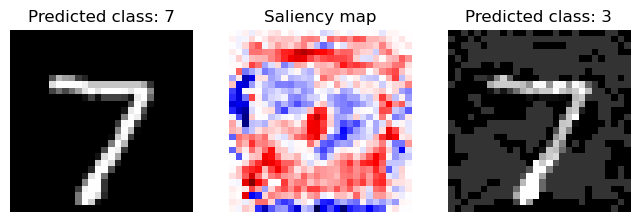

In [12]:
plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.imshow(x.squeeze().detach(), cmap='gray')
plt.title(f"Predicted class: {pred.item()}")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(grad.squeeze().detach(), cmap='seismic')
plt.title("Saliency map")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(x_mod.squeeze().detach(), cmap='gray')
plt.title(f"Predicted class: {pred_mod.item()}")
plt.axis('off')

plt.show()

La prima immagine è quella originale, la terza è quella modificata.
Sono molto simili.

La seconda mi dà un informazione su quali pixel sono più sensibili a questa variazione.

Il modello non riconosce più l'immagine.

## Exercise

Consider the simple ODE shown as first example today:

$ \frac{dy}{dt} = -ky $

with parameter $k=0.4$ and initial condition $y_0 = 6$.

* Apply the two methods seen today to study the system.
* How would the results change if random samples were generated using the Van der Corput sequence?